# Hypothesis Testing

## Objective

Apply statistical hypothesis testing to determine whether seasonal conditions have a significant effect on wind turbine power generation.

## Research Questions

1. Does the average power generation differ between Summer and Winter?

2. Does season have a significant effect on power generation?

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats


In [2]:
df = pd.read_csv("../data/processed/wind_turbine.csv")

df.head()

,date_time,actual_power_kW,wind_speed_m/s,theoretical_power_kW,wind_direction_deg,month,year,hour,power_delta,eff,season,wind_dir,performance_flag
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,1,2018,0,36.281117,0.912855,Winter,W,Normal
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,1,2018,0,66.148316,0.872772,Winter,W,Normal
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,1,2018,0,84.523429,0.783772,Winter,W,Underperforming
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,1,2018,0,96.481664,0.813066,Winter,W,Normal
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,1,2018,0,111.052276,0.774148,Winter,W,Underperforming


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (42781, 13)

Columns:
['date_time', 'actual_power_kW', 'wind_speed_m/s', 'theoretical_power_kW', 'wind_direction_deg', 'month', 'year', 'hour', 'power_delta', 'eff', 'season', 'wind_dir', 'performance_flag']


In [5]:
print(df['season'].value_counts())

season
Summer    11006
Autumn    10724
Spring    10636
Winter    10415
Name: count, dtype: int64


## Data Preparation

Extract Summer and Winter observations from the processed dataset for comparison.

In [8]:
summer = df[df['season'] == 'Summer']['actual_power_kW']
winter = df[df['season'] == 'Winter']['actual_power_kW']

In [9]:
df[df['season'] == 'Summer']

,date_time,actual_power_kW,wind_speed_m/s,theoretical_power_kW,wind_direction_deg,month,year,hour,power_delta,eff,season,wind_dir,performance_flag
17401,2018-06-01 00:00:00,757.624878,6.662233,870.926587,40.313850,6,2018,0,113.301709,0.869907,Summer,NE,Normal
17402,2018-06-01 00:10:00,672.312805,6.392141,764.442293,43.528149,6,2018,0,92.129488,0.879481,Summer,NE,Normal
17403,2018-06-01 00:20:00,586.302002,6.162780,680.292725,43.875511,6,2018,0,93.990723,0.861838,Summer,NE,Normal
17404,2018-06-01 00:30:00,712.472778,6.714572,892.515762,45.382710,6,2018,0,180.042983,0.798275,Summer,NE,Normal
17405,2018-06-01 00:40:00,647.808716,6.583013,838.846907,47.362591,6,2018,0,191.038191,0.772261,Summer,NE,Underperforming
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28402,2018-08-31 23:10:00,3375.918945,12.702540,3591.174686,71.050377,8,2018,23,215.255741,0.940060,Summer,E,Normal
28403,2018-08-31 23:20:00,3397.344971,12.996810,3597.932750,71.666801,8,2018,23,200.587779,0.944249,Summer,E,Normal
28404,2018-08-31 23:30:00,3367.871094,12.649030,3588.589812,72.324600,8,2018,23,220.718718,0.938494,Summer,E,Normal
28405,2018-08-31 23:40:00,3371.726074,12.695070,3590.839284,72.622223,8,2018,23,219.113210,0.938980,Summer,E,Normal


In [10]:
['actual_power_kW']

['actual_power_kW']

In [11]:
print("Summer observations :", len(summer))
print("Winter observations :", len(winter))

Summer observations : 11006
Winter observations : 10415


In [11]:
print("Summer Statistics")
print(summer.describe())

print("\n")

print("Winter Statistics")
print(winter.describe())

Summer Statistics
count    11006.000000
mean      1372.704567
std       1158.646629
min         -0.413933
25%        354.406975
50%       1036.961487
75%       2316.933044
max       3618.732910
Name: actual_power_kW, dtype: float64


Winter Statistics
count    10415.000000
mean      1569.291833
std       1405.512223
min         -2.471405
25%        157.864449
50%       1198.470947
75%       3216.435059
max       3604.561035
Name: actual_power_kW, dtype: float64


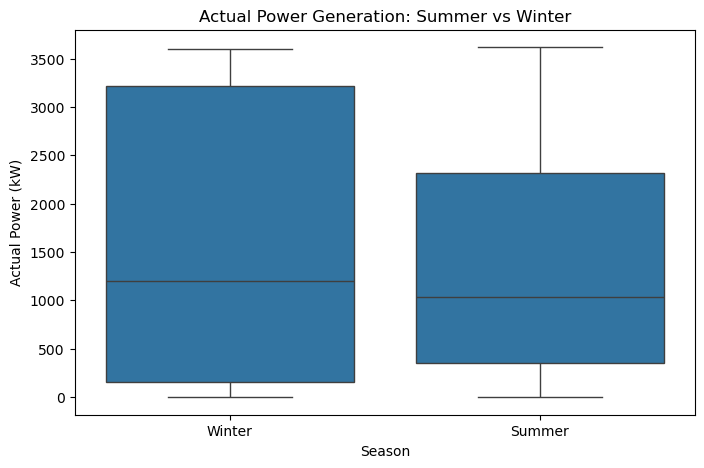

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df[df['season'].isin(['Summer', 'Winter'])],
    x='season',
    y='actual_power_kW'
)

plt.title("Actual Power Generation: Summer vs Winter")
plt.xlabel("Season")
plt.ylabel("Actual Power (kW)")

plt.show()

## Initial Observations

Descriptive statistics and boxplots provide a preliminary comparison between Summer and Winter before performing the hypothesis test.

## Hypothesis

H0 : mu_summer = mu_winter

H1 : mu_summer != mu_winter

alpha = 0.05

In [13]:
alpha = 0.05

print(f"Significance Level alpha: {alpha}")

Significance Level alpha: 0.05


In [6]:
print("Null Hypothesis (H0):")
print("mu_summer = mu_winter")
print("There is no significant difference in the average actual power generated during Summer and Winter.")

print("\nAlternative Hypothesis (H1):")
print("mu_summer != mu_winter")
print("There is a significant difference in the average actual power generated during Summer and Winter.")

Null Hypothesis (H0):
mu_summer = mu_winter
There is no significant difference in the average actual power generated during Summer and Winter.

Alternative Hypothesis (H1):
mu_summer != mu_winter
There is a significant difference in the average actual power generated during Summer and Winter.


## Two-Sample T-Test

Compare the average actual power generated during Summer and Winter.

In [14]:
t_stat, p_value = stats.ttest_ind(
    summer,
    winter,
    equal_var=False
)

print("T-Statistic :", t_stat)
print("P-Value :", p_value)

T-Statistic : -11.135802603965914
P-Value : 1.0181543544816082e-28


In [15]:
if p_value < alpha:
    print("Decision : Reject H0")
    print("Conclusion : There is a significant difference in average power generation between Summer and Winter.")
else:
    print("Decision : Fail to Reject H0")
    print("Conclusion : There is no significant difference in average power generation between Summer and Winter.")

Decision : Reject H0
Conclusion : There is a significant difference in average power generation between Summer and Winter.


### Interpretation

The decision is based on comparing the p-value with alpha = 0.05.

## Type I & Type II Error

**Type I Error**

Reject H0 when H0 is actually true.

**Project Example:** Concluding that Summer and Winter have different average power generation when they actually do not.

---

**Type II Error**

Fail to reject H0 when H0 is actually false.

**Project Example:** Concluding that Summer and Winter have the same average power generation when they actually differ.

---

**Practical Implications**

- Type I Error may lead to unnecessary operational or maintenance decisions.
- Type II Error may cause a real seasonal effect on turbine performance to be overlooked.

## One-Way ANOVA

One-Way ANOVA is used to determine whether the average actual power generation differs across the four seasons.

H0 : All seasonal mean power generations are equal.

H1 : At least one seasonal mean is different.

alpha = 0.05

In [18]:
winter = df[df['season'] == 'Winter']['actual_power_kW']
spring = df[df['season'] == 'Spring']['actual_power_kW']
summer = df[df['season'] == 'Summer']['actual_power_kW']
autumn = df[df['season'] == 'Autumn']['actual_power_kW']

In [19]:
f_stat, p_value = stats.f_oneway(
    winter,
    spring,
    summer,
    autumn
)

print("F-Statistic :", f_stat)
print("P-Value :", p_value)

F-Statistic : 151.47773372342297
P-Value : 1.1773080942366716e-97


In [20]:
if p_value < alpha:
    print("Decision : Reject H0")
    print("Conclusion : At least one season has a significantly different average power generation.")
else:
    print("Decision : Fail to Reject H0")
    print("Conclusion : There is no significant difference in average power generation across the seasons.")

Decision : Reject H0
Conclusion : At least one season has a significantly different average power generation.


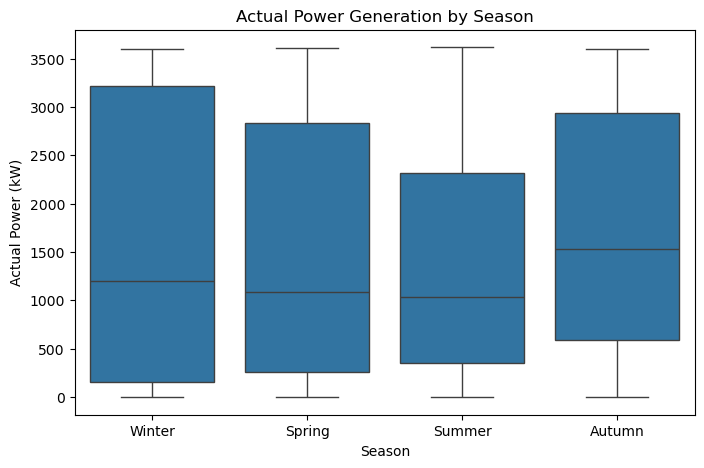

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='season',
    y='actual_power_kW'
)

plt.title("Actual Power Generation by Season")
plt.xlabel("Season")
plt.ylabel("Actual Power (kW)")

plt.show()

## Interpretation

The ANOVA test determines whether seasonal changes have a significant effect on the wind turbine's average power generation. The final decision is based on comparing the p-value with alpha = 0.05.

## Conclusion

- The Independent Two-Sample T-Test was used to compare the average actual power generation between Summer and Winter.
- The One-Way ANOVA was performed to compare the average power generation across all four seasons.
- Based on the p-values obtained, statistical decisions were made at a significance level of alpha = 0.05.
- The results help determine whether seasonal conditions have a significant impact on wind turbine power generation.